### Setup

In [1]:
# Library
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import torch
import random
import numpy as np
from datetime import datetime
import json
from datasets import Dataset, DatasetDict
from tqdm import tqdm
from PIL import Image
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import login
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.training_utils import cast_training_params
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict

# GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device : ',device)   

# CONFIG
device = 'cuda' if torch.cuda.is_available() else 'cpu'
CURRENT_TIME = datetime.now().strftime("%Y%m%d_%H%M%S")
MASTER_SEED = 42

# TRAIN PARAMETER
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
EPOCHS = 50
LEARNING_RATE = 1e-04
TRAIN_DATA_SIZE = 2024 # 2024
TEST_DATA_SIZE = 506 # 506

# PATH
CONFIG_PATH = '../config.json'
with open(CONFIG_PATH,'r') as f:
    config = json.load(f)
## DATA
TRAIN_IMAGE_FOLDER = config.get("TRAIN_IMAGE_FOLDER") # change data path
TRAIN_LABEL_FOLDER = config.get("TRAIN_LABEL_EXPAND_FOLDER") # change data path
TRAIN_IMAGE_FILE = sorted([f for f in os.listdir(TRAIN_IMAGE_FOLDER) if f.endswith(('.jpg', '.jpeg', '.png'))], key=lambda x: int(x.split('.')[0]))[:TRAIN_DATA_SIZE]
TRAIN_LABEL_FILE = sorted([f for f in os.listdir(TRAIN_LABEL_FOLDER) if f.endswith('.json')], key=lambda x: int(x.split('.')[0]))[:TRAIN_DATA_SIZE]

# TRAIN_IMAGE_FOLDER = config.get("ZARA_IMAGE_FOLDER") # change data path
# TRAIN_LABEL_FOLDER = config.get("ZARA_LABEL_FOLDER") # change data path
# TRAIN_IMAGE_FILE = sorted([f for f in os.listdir(TRAIN_IMAGE_FOLDER) if f.endswith(('.jpg', '.jpeg', '.png'))], key=lambda x: int(x.split('.')[0][4:]))[:TRAIN_DATA_SIZE]
# TRAIN_LABEL_FILE = sorted([f for f in os.listdir(TRAIN_LABEL_FOLDER) if f.endswith('.json')], key=lambda x: int(x.split('.')[0][4:]))[:TRAIN_DATA_SIZE]

## MODEL
PRE_TRAINED_MODEL_NAME="stablediffusionapi/deliberate-v2"
SAVE_MODEL_PATH = f"../Experiment/model/FIGMA_{CURRENT_TIME}"
SAVE_WEIGHTS_PATH = f"../Experiment/model_weights/FIGMA_weights_{CURRENT_TIME}"

## HUGGINGFACE
HUGGING_FACE_TOKEN = config.get("HUGGING_FACE_TOKEN")
login(HUGGING_FACE_TOKEN)

2025-06-10 14:37:27.785560: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-10 14:37:27.826443: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-10 14:37:28.502666: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


device :  cuda
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /home/gayeon39/.cache/huggingface/token
Login successful


### Load Model

In [6]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)
tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)
print("Tokenizer max length:", tokenizer.model_max_length)

/home/gayeon39/miniconda3/envs/figma/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizer max length: 77


### Preprocess Data

In [7]:
# Function that tokenize a text column from a given data sample and returns a token ID tensor.
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []
    for caption in examples[caption_column]:
        # if cation is one
        if isinstance(caption, str):
            captions.append(caption)
        # if caption is over one, ramdomly select one 
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )
    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

# Transformation pipeline to preprocess image data for training
transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if True else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if True else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

# A function that converts image data to RGB, preprocesses it, and tokenize the text column to construct a training dataset
def preprocess_data(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]
    # Process image
    examples["pixel_values"] = [transforms(image) for image in images]
    # Process text
    examples["input_ids"] = tokenize_captions(examples)
    return examples

# A function that stacks images and token IDs in batches and converts them into PyTorch tensor forms
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W): Stack N
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # same with tensor.contiguous() 
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    # {(77,), ..., (77,)}_N개 -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}

- Train Data

In [7]:
data = []
for image_file, label_file in zip(sorted(TRAIN_IMAGE_FILE), sorted(TRAIN_LABEL_FILE)):
    prefix_img = os.path.splitext(image_file)[0]
    prefix_lbl = os.path.splitext(label_file)[0]
    
    if prefix_img != prefix_lbl:
        print(f"❌ Prefix mismatch: {image_file} vs {label_file}")
        continue
    
    image_path = os.path.join(TRAIN_IMAGE_FOLDER, image_file)
    label_path = os.path.join(TRAIN_LABEL_FOLDER, label_file)

    try:
        with open(image_path, 'rb') as image:
            image_data = Image.open(image).convert('RGB')
            image_data.load()  

        with open(label_path, 'r') as label:
            label_data = json.load(label)

        data.append({
            'image': image_data,
            'text': label_data
        })
    except Exception as e:
        print(f"⚠️ Error : {image_file}, {label_file} → {e}")

In [8]:
# train data
dataset = Dataset.from_dict({
    'image': [item['image'] for item in data],
    'text': [item['text'] for item in data]
})

# nike, zara data
# dataset = Dataset.from_dict({
#     'image': [item['image'] for item in data],
#     'text': [item['text']['Summary'] for item in data]
# })

# Generate Train DatasetDict
train_dataset = DatasetDict({'train': dataset})

# Generate Train Data Loader
train_dataset = train_dataset.with_transform(preprocess_data)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print(train_dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 180
    })
})


- Checking Data 

In [9]:
train_dataloader_iter = iter(train_dataloader)
mini_batch = next(train_dataloader_iter)
print('Image Data : ', mini_batch['pixel_values'].shape)
print('Caption Data : ', mini_batch['input_ids'].shape)

Image Data :  torch.Size([4, 3, 512, 512])
Caption Data :  torch.Size([4, 77])


### Train Setting

In [10]:
# Setting FP16 for AMP application
weight_dtype = torch.float16 
# The unet, vae, and text encoder are not trained during fine-tuning
unet.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False);

# LoRA Adapter 준비
LORA_RANK = 4
# Freeze the unet parameters before adding adapters
for param in unet.parameters():
    param.requires_grad_(False)
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
# Move models to GPU
text_encoder.to(device);
vae.to(device);
unet.to(device);
unet.add_adapter(unet_lora_config)

# Cast the trainable parameters to float32
if weight_dtype == torch.float16:
    # only upcast trainable parameters (LoRA) into fp32
    cast_training_params(unet, dtype=torch.float32)

lora_layers = filter(lambda p: p.requires_grad, unet.parameters())

# Set Optimizer
optimizer = torch.optim.AdamW(
        lora_layers,
        lr=LEARNING_RATE,
    )
# Set Scheduler
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

### Train Loop

In [11]:
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
prediction_type = None  
train_losses = []

for epoch in range(EPOCHS):
    unet.train()
    text_encoder.train()
    vae.train()
    
    for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
        with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
            # latent encoding
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
            
            # Add noise and generate timestep
            noise = torch.randn_like(latents)
            bsz = latents.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            
            # Extract Text Embedding
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
            if prediction_type is not None:
                noise_scheduler.register_to_config(prediction_type=prediction_type)
            if noise_scheduler.config.prediction_type == "epsilon":
                target = noise
            elif noise_scheduler.config.prediction_type == "v_prediction":
                target = noise_scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")
            
            # Calculate loss after noise prediction with UNet
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
        
        train_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        optimizer.zero_grad()
    
    avg_train_loss = sum(train_losses[-100:]) / 100
    print(f'Finished epoch {epoch+1}. Average training loss (last 100): {avg_train_loss:05f}')

/tmp/ipykernel_3721666/1153460170.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/50: 100%|██████████| 45/45 [00:13<00:00,  3.32it/s]


Finished epoch 1. Average training loss (last 100): 0.046752


Epoch 2/50: 100%|██████████| 45/45 [00:13<00:00,  3.46it/s]


Finished epoch 2. Average training loss (last 100): 0.091156


Epoch 3/50: 100%|██████████| 45/45 [00:13<00:00,  3.45it/s]


...

Finished epoch 48. Average training loss (last 100): 0.089933


Epoch 49/50: 100%|██████████| 45/45 [00:13<00:00,  3.38it/s]


Finished epoch 49. Average training loss (last 100): 0.094841


Epoch 50/50: 100%|██████████| 45/45 [00:13<00:00,  3.39it/s]

Finished epoch 50. Average training loss (last 100): 0.105540


### Construct Pipeline

In [12]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.to(device);

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/gayeon39/miniconda3/envs/figma-env/lib/python3.10/site-packages/transformers/models/clip/feature_extraction_clip.py:30: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


### Save Fine-Tuned Model

In [13]:
# Save model 
pipeline.save_pretrained(SAVE_MODEL_PATH)
# Save model weights
unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
StableDiffusionPipeline.save_lora_weights(
    save_directory=SAVE_WEIGHTS_PATH,
    unet_lora_layers=unet_lora_state_dict,
    safe_serialization=True,
)

### Load Fine-Tuning Model
- During LoRA Fine-Tuning, only LoRA parameters added to the base model (UNet of Stable diffusion) are updated, and the original weight of the base model is stored X
- Saved pipelines contain only UNet's default weight X, LoRA delta
- Apply Fine-tuned LoRA weights after loading the base model separately

In [14]:
# Load Saved Model
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16).to(device)
pipe.load_lora_weights(SAVE_WEIGHTS_PATH, safe_serialization=True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

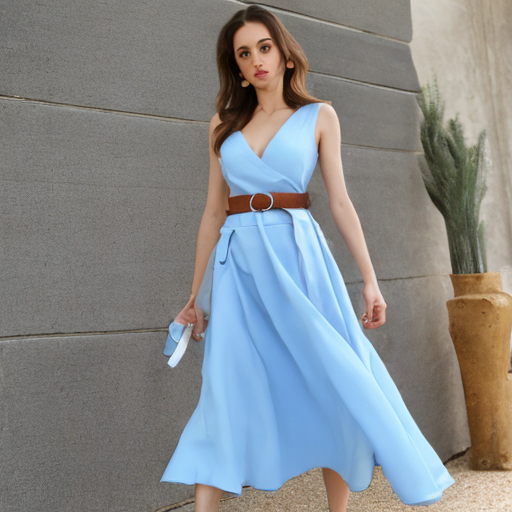

In [15]:
# expand new model : FIGMA_weights_20250604_234758
# Create an image based on prompt
prompt = "a sky blue dress with a brown belt and a white shoes"
generated_image = pipe(prompt).images[0]
generated_image

In [16]:
# train_image_kfashion, train_label_clip_expand
SAVE_MODEL_PATH

'../Experiment/model/FIGMA_20250605_221148'